In [53]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fft(signal, fs):
    """
    Plots the FFT of a given signal and annotates the maximum amplitude.

    Parameters:
    signal (numpy array): Input signal.
    fs (float): Sampling frequency of the signal in Hz.
    """
    # Compute the FFT of the signal
    N = len(signal)
    T = 1.0 / fs
    yf = np.fft.fft(signal)
    xf = np.fft.fftfreq(N, T)[:N//2]

    # Compute the amplitude spectrum
    amplitude_spectrum = 2.0/N * np.abs(yf[:N//2])

    # Find the peak frequency
    max_index = np.argmax(amplitude_spectrum)  # Index of max amplitude
    peak_freq = xf[max_index]  # Frequency at max amplitude
    peak_amplitude = amplitude_spectrum[max_index]  # Max amplitude value

    # Plot the amplitude spectrum
    plt.figure(figsize=(10, 6))
    plt.plot(xf, amplitude_spectrum, label="FFT Spectrum")
    
    # Annotate the max peak
    plt.scatter(peak_freq, peak_amplitude, color='red', label=f'Peak: {peak_freq:.2f} Hz')
    plt.text(peak_freq, peak_amplitude, f"{peak_freq:.2f} Hz", fontsize=12, verticalalignment='bottom', horizontalalignment='right')

    # Labels and title
    plt.title('FFT of the Signal test1 (6.4Hz, 0.2g)')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid()
    
    # Show the plot
    plt.show()
    
    # Print the peak frequency for reference
    print(f"Peak Frequency: {peak_freq:.2f} Hz, Amplitude: {peak_amplitude:.4f}")



In [51]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fft(signal, fs):
    """
    Plots the FFT of a given signal.

    Parameters:
    signal (numpy array): Input signal.
    fs (float): Sampling frequency of the signal in Hz.
    """
    # Compute the FFT of the signal
    N = len(signal)
    T = 1.0 / fs
    yf = np.fft.fft(signal)
    xf = np.fft.fftfreq(N, T)[:N//2]

    # Compute the amplitude spectrum
    amplitude_spectrum = 2.0/N * np.abs(yf[:N//2])

    # Plot the amplitude spectrum
    plt.figure(figsize=(10, 6))
    plt.plot(xf, amplitude_spectrum)
    plt.title('FFT of the Signal test1 (6.4Hz, 0.2g)')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.grid()
    plt.show()
    print(np.argmax(amplitude_spectrum))



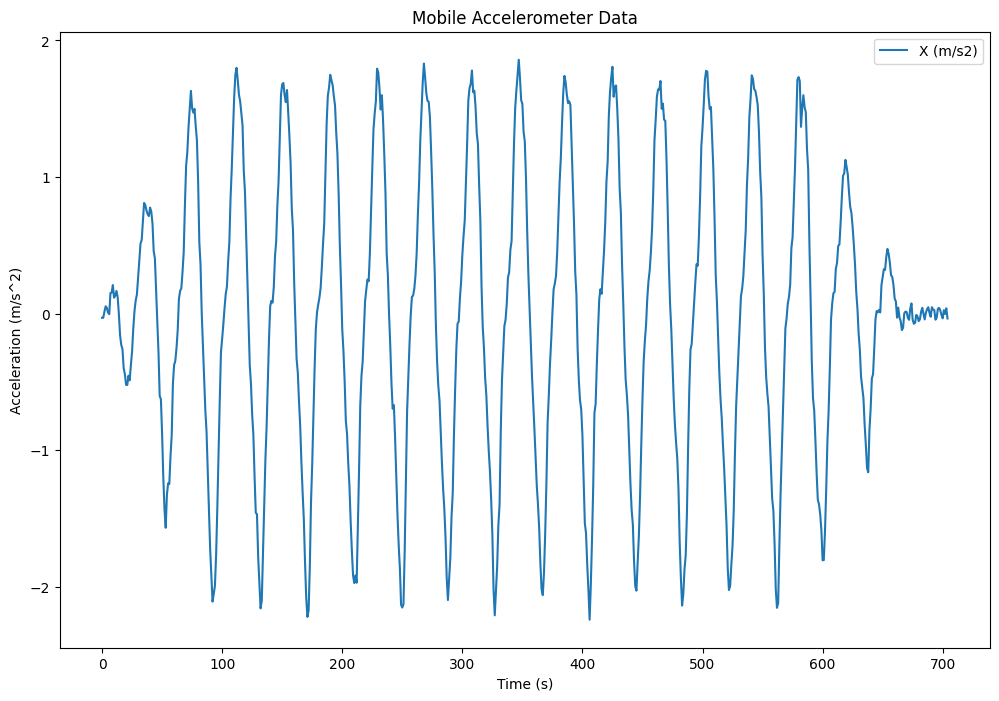

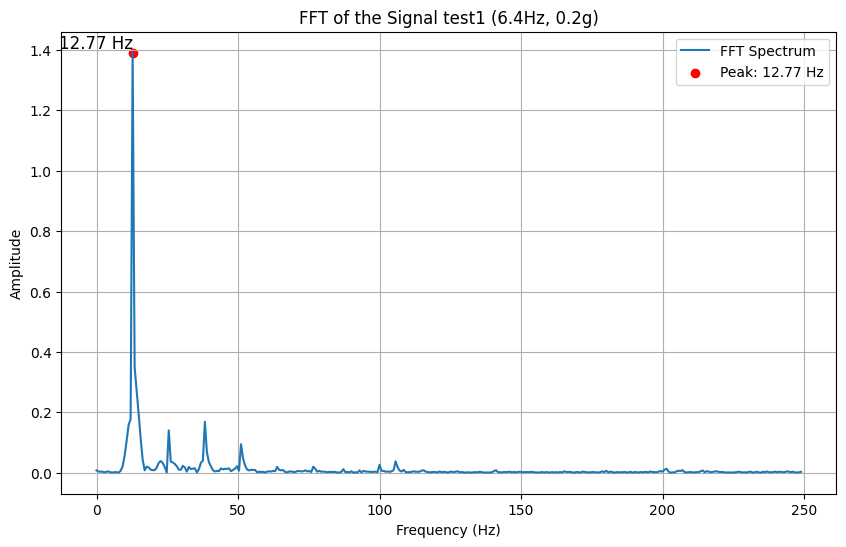

Peak Frequency: 12.77 Hz, Amplitude: 1.3910


In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np

df = pd.read_csv(r"D:\Users\dibra\Desktop\earthquake\shaking table 1\huawei(original)\Accelerometer Data 0001.txt", skiprows=3, delimiter=',', skipinitialspace=True)



mobile = df['X (m/s2)']

# Plot the data
plt.figure(figsize=(12, 8))

plt.plot( mobile, label='X (m/s2)')
# Adding labels and title
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.title('Mobile Accelerometer Data')
plt.legend()

# Show the plot
plt.show()


plot_fft((df['X (m/s2)']), 500)

In [14]:
import os
import pandas as pd

def process_keuwl_files(input_folder, output_folder):
    os.makedirs(output_folder, exist_ok=True)

    for filename in os.listdir(input_folder):
        if filename.endswith('.txt'):
            input_path = os.path.join(input_folder, filename)

            # Read the file skipping the first 3 lines
            df = pd.read_csv(input_path, skiprows=3)

            # Rename columns
            df = df.rename(columns={
                " X (g)": "Acceleration x (m/s^2)",
                " Y (g)": "Acceleration y (m/s^2)",
                " Z (g)": "Acceleration z (m/s^2)"
            })

            # Drop unwanted columns
            df = df.drop(columns=[" R (g)", " Theta (deg)", " Phi (deg)"])

            # Calculate sample rate
            time_deltas = df["Time (s)"].diff().dropna()
            mean_delta = time_deltas.mean()
            sample_rate = round(1 / mean_delta)

            # Print filename and sample rate
            print(f"✅ {filename}: Sample Rate = {sample_rate} Hz")

            # Save to CSV
            output_filename = filename.replace('.txt', '.csv')
            output_path = os.path.join(output_folder, output_filename)
            df.to_csv(output_path, index=False)

if __name__ == "__main__":
    input_folder = "all data"       # Folder with .txt files
    output_folder = "all data"  # Folder for cleaned CSV files

    process_keuwl_files(input_folder, output_folder)


✅ Accelerometer Data 0006.txt: Sample Rate = 250 Hz


In [19]:
import os
import pandas as pd
import numpy as np
from scipy.signal import resample

def resample_file(file_path, output_folder, target_rate=100):
    df = pd.read_csv(file_path)

    # Find which time column we have
    time_column = None
    for col in df.columns:
        if 'time' in col.lower():
            time_column = col
            break

    if time_column is None:
        print(f"❌ No Time column found in {file_path}")
        return

    # Calculate original sample rate
    time_deltas = df[time_column].diff().dropna()
    mean_delta = time_deltas.mean()
    original_rate = 1 / mean_delta
    sample_rate_rounded = round(original_rate)

    print(f"✅ {os.path.basename(file_path)}: Original Sample Rate ≈ {sample_rate_rounded} Hz")

    # Number of samples after resampling
    num_samples = int(len(df) * target_rate / original_rate)

    # Resample all columns except Time
    data_columns = [col for col in df.columns if col != time_column]
    resampled_data = {}

    for col in data_columns:
        resampled_data[col] = resample(df[col].values, num_samples)

    # Rebuild perfect Time vector (0, 0.01, 0.02, ..., for 100 Hz)
    new_time = np.arange(0, num_samples) / target_rate
    resampled_data[time_column] = new_time

    # Create new DataFrame
    df_resampled = pd.DataFrame(resampled_data)
    df_resampled = df_resampled[[time_column] + data_columns]  # reorder columns

    # Save resampled file
    os.makedirs(output_folder, exist_ok=True)
    output_path = os.path.join(output_folder, os.path.basename(file_path))
    df_resampled.to_csv(output_path, index=False)

def resample_all_files(input_folder, output_folder):
    for filename in os.listdir(input_folder):
        if filename.endswith('.csv'):
            file_path = os.path.join(input_folder, filename)
            resample_file(file_path, output_folder)

if __name__ == "__main__":
    input_folder = "aligned"       # Folder where the current CSV files are
    output_folder = "test1_resampled"  # Folder to save the resampled files

    resample_all_files(input_folder, output_folder)


✅ 09-0.2-4.csv: Original Sample Rate ≈ 250 Hz


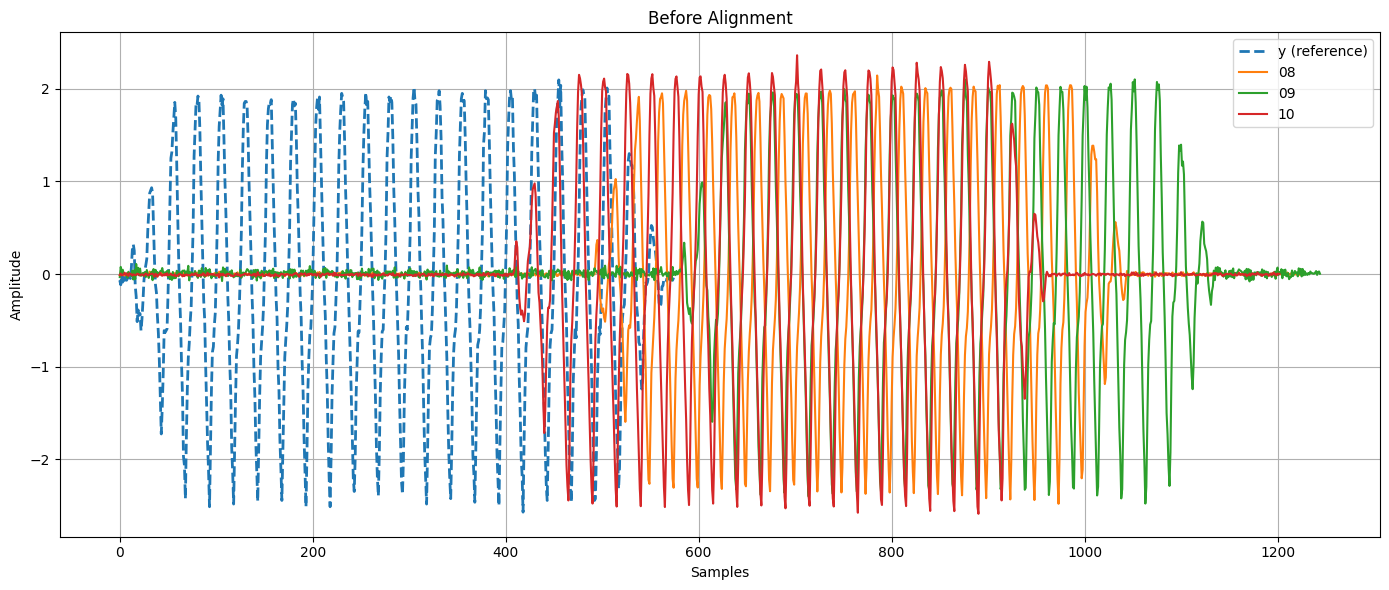

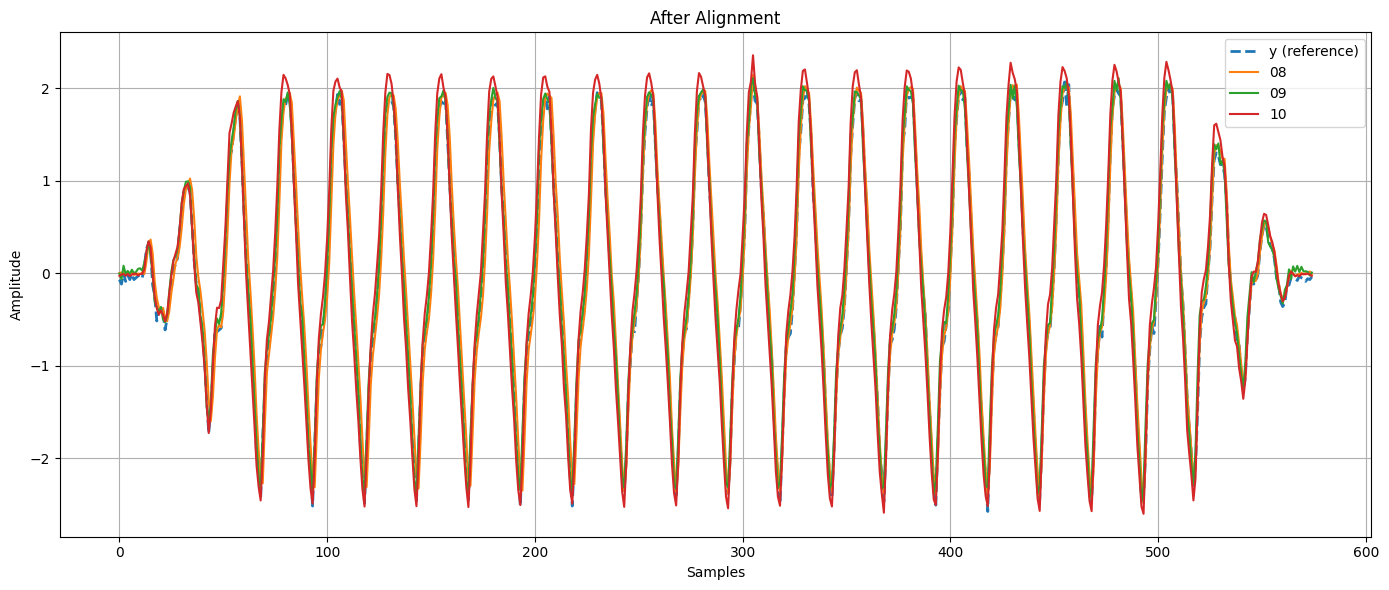

✅ Aligned signals saved to 'aligned_signals.csv'.


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import correlate
from scipy.signal import resample

def align_to_reference(reference, signals):
    aligned_signals = []

    for signal in signals:
        correlation = correlate(signal, reference, mode='full')
        lag = correlation.argmax() - (len(reference) - 1)

        if lag > 0:
            aligned = signal[lag:]
            ref_aligned = reference[:len(aligned)]
        else:
            ref_aligned = reference[-lag:]
            aligned = signal[:len(ref_aligned)]

        min_len = min(len(ref_aligned), len(aligned))
        aligned = aligned[:min_len]
        aligned_signals.append(aligned)

    # Force output to 2D (signals, samples)
    aligned_signals = np.atleast_2d(aligned_signals)

    return aligned_signals

def plot_signals(reference, signals, signal_names, title):
    plt.figure(figsize=(14, 6))
    plt.title(title)
    plt.plot(reference, label='y (reference)', linewidth=2, linestyle='--')

    for signal, name in zip(signals, signal_names):
        plt.plot(signal-np.mean(signal), label=name)

    plt.legend()
    plt.xlabel('Samples')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# --- Example usage ---
if __name__ == "__main__":
    new_rate = 100
    acc= "0.2"
    freq="4"
    # Example signals (replace these with your real signals)
    y = pd.read_csv("acc/22-"+acc+"-"+freq+".csv")['Acceleration x (m/s^2)'].values

    x0 = pd.read_csv("test1_resampled/08-"+acc+"-"+freq+".CSV")['Acceleration x (m/s^2)'].values
    
    x1 = pd.read_csv("test1_resampled/09-"+acc+"-"+freq+".CSV")['Acceleration x (m/s^2)'].values
    num_samples = int(len(x1) * new_rate / 250)
    x1 = resample(x1, num_samples)
    
    x2 = pd.read_csv("test1_resampled/10-"+acc+"-"+freq+".CSV")['Acceleration x (m/s^2)'].values
    

    
    # Create x5 to x8 if needed

    signals = [x0,x1, x2]  # Add x5, ..., x8 here
    signal_names = ['08','09', '10']  # Names for plotting and CSV

    # Plot signals before alignment
    plot_signals(y, signals, signal_names, title="Before Alignment")

    # Align signals
    aligned_signals = align_to_reference(y, signals)

    # Cut reference to match the aligned signals' length
    y_cut = y[:aligned_signals.shape[1]]

    # Plot signals after alignment
    plot_signals(y_cut, aligned_signals, signal_names, title="After Alignment")

    # Save aligned signals + reference to CSV
    all_signals = np.vstack([y_cut, aligned_signals])  # First row: reference
    columns = ['22'] + signal_names

    df = pd.DataFrame(all_signals.T, columns=columns)
    df.to_csv("alignment/"+acc+"-"+freq+".csv", index=False)

    print("✅ Aligned signals saved to 'aligned_signals.csv'.")


In [20]:
import os
import pandas as pd
import numpy as np
from scipy.signal import resample, correlate

# Mapping from id to original sampling rates
original_rates = {
    "08": 100,
    "09": 100,
    "10": 100
}

def resample_dataframe(df, original_rate, target_rate=100):
    num_samples = int(len(df) * target_rate / original_rate)
    resampled_data = {}

    for column in df.columns:
        resampled_data[column] = resample(df[column].values, num_samples)

    return pd.DataFrame(resampled_data)

def align_full_file(file_path, reference_path, output_folder, file_id):
    # Read both files
    df = pd.read_csv(file_path)
    df_ref = pd.read_csv(reference_path)

    # Resample both to 100 Hz
    original_rate = original_rates.get(file_id)
    if original_rate is None:
        print(f"⚠️ Unknown sampling rate for {file_id}. Skipping.")
        return

    # Get reference's original rate (always 100 for id '11')
    ref_original_rate = 100  # Assuming reference is already at 100 Hz

    df_resampled = resample_dataframe(df, original_rate)
    df_ref_resampled = resample_dataframe(df_ref, ref_original_rate)

    # Align based on 'Acceleration x (m/s^2)' column
    signal = df_resampled['Acceleration x (m/s^2)'].values
    ref_signal = df_ref_resampled['Acceleration x (m/s^2)'].values

    correlation = correlate(signal, ref_signal, mode='full')
    lag = correlation.argmax() - (len(ref_signal) - 1)

    if lag > 0:
        df_aligned = df_resampled.iloc[lag:].reset_index(drop=True)
        df_ref_aligned = df_ref_resampled.iloc[:len(df_aligned)].reset_index(drop=True)
    else:
        df_ref_aligned = df_ref_resampled.iloc[-lag:].reset_index(drop=True)
        df_aligned = df_resampled.iloc[:len(df_ref_aligned)].reset_index(drop=True)

    # Match lengths exactly
    min_len = min(len(df_aligned), len(df_ref_aligned))
    df_aligned = df_aligned.iloc[:min_len]

    # Save aligned file
    filename = os.path.basename(file_path)
    output_path = os.path.join(output_folder, filename)
    df_aligned.to_csv(output_path, index=False)
    print(f"✅ Resampled, aligned, and saved: {output_path}")

def process_all_files(input_folder, output_folder):
    os.makedirs(output_folder, exist_ok=True)

    for filename in os.listdir(input_folder):
        if filename.endswith('.csv'):
            file_id = filename.split('-')[0]
            input_path = os.path.join(input_folder, filename)

            # Build reference file path
            parts = filename.split('-')
            if len(parts) < 3:
                print(f"⚠️ Skipping file (unexpected name format): {filename}")
                continue
            reference_filename = '22-' + '-'.join(parts[1:])
            reference_path = os.path.join(input_folder, reference_filename)

            if not os.path.exists(reference_path):
                print(f"❌ Reference file not found for {filename}: expected {reference_filename}")
                continue

            # Align and save
            align_full_file(input_path, reference_path, output_folder, file_id)

# Example run
if __name__ == "__main__":
    input_folder = "all data"  # Folder where your original files are
    output_folder = "aligned"  # Where the new aligned, resampled files will go

    process_all_files(input_folder, output_folder)


✅ Resampled, aligned, and saved: aligned\08-0.1-2.csv
✅ Resampled, aligned, and saved: aligned\08-0.1-6.4.csv
✅ Resampled, aligned, and saved: aligned\08-0.2-4.csv
✅ Resampled, aligned, and saved: aligned\08-0.2-6.4.csv
✅ Resampled, aligned, and saved: aligned\08-0.2-8.csv
✅ Resampled, aligned, and saved: aligned\08-0.3-6.4.csv
✅ Resampled, aligned, and saved: aligned\08-0.4-8.csv
✅ Resampled, aligned, and saved: aligned\08-0.7-6.4.csv
✅ Resampled, aligned, and saved: aligned\09-0.1-2.csv
✅ Resampled, aligned, and saved: aligned\09-0.1-6.4.csv
✅ Resampled, aligned, and saved: aligned\09-0.2-4.csv
✅ Resampled, aligned, and saved: aligned\09-0.2-6.4.csv
✅ Resampled, aligned, and saved: aligned\09-0.2-8.csv
✅ Resampled, aligned, and saved: aligned\09-0.3-6.4.csv
✅ Resampled, aligned, and saved: aligned\09-0.4-8.csv
✅ Resampled, aligned, and saved: aligned\09-0.7-6.4.csv
✅ Resampled, aligned, and saved: aligned\10-0.1-2.csv
✅ Resampled, aligned, and saved: aligned\10-0.1-6.4.csv
✅ Resample